# VisionGuard AI — CNN Autoencoder Model Training

Clean, training-focused notebook for VisionGuard AI.

The notebook:

- uses only `train/good` normal images
- automatically discovers the selected MVTec categories
- avoids hard-coded absolute dataset locations
- creates a fresh TensorFlow dataset inside the training workflow
- does not depend on a pre-existing `tf_datasets` variable
- tests the model before full training
- trains one independent CNN autoencoder per category
- saves tables as CSV
- saves plots as PNG and Plotly HTML
- saves trained models and weights

## Install dependencies

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
    "plotly": "plotly",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "kagglehub": "kagglehub",
}

missing = [
    package
    for module_name, package in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing,
        ]
    )

print("Dependencies ready.")


Dependencies ready.


## Imports

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split

import kagglehub

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ImageFile.LOAD_TRUNCATED_IMAGES = False
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


/home/as178/VisionGuard-AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.20.0
NumPy: 2.5.3
Pandas: 3.0.6


## Configuration

In [3]:
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
}

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
IMAGE_CHANNELS = 3

BATCH_SIZE = 32
EPOCHS = 40
VALIDATION_SIZE = 0.10

LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 1e-6

EARLY_STOPPING_PATIENCE = 7
LR_REDUCTION_PATIENCE = 3
LR_REDUCTION_FACTOR = 0.5

SEED = 42

TABLE_DIR = Path("table")
IMAGE_DIR = Path("images")
MODEL_DIR = Path("models")

for folder in (
    TABLE_DIR,
    IMAGE_DIR,
    MODEL_DIR,
):
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration ready.")


Configuration ready.


## GPU check

In [4]:
gpus = tf.config.list_physical_devices("GPU")

print("GPU count:", len(gpus))

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True,
        )
    except RuntimeError:
        pass

if gpus:
    print("GPU available.")
else:
    print("CPU training will be used.")


GPU count: 1
GPU available.


## Dataset discovery helpers

In [5]:
def is_image_file(path):
    return (
        path.is_file()
        and path.suffix.lower()
        in IMAGE_EXTENSIONS
    )


def has_good_folder(category, base):
    matches = []

    try:
        matches.extend(
            base.rglob(
                f"{category}/train/good"
            )
        )
    except Exception:
        pass

    for folder in matches:
        if folder.is_dir():
            files = [
                p
                for p in folder.rglob("*")
                if is_image_file(p)
            ]

            if files:
                return folder, sorted(files)

    return None, []


def discover_category_files():
    base = Path.cwd()

    result = {}

    for category in CATEGORIES:
        folder, files = has_good_folder(
            category,
            base,
        )

        if files:
            result[category] = {
                "folder": folder,
                "files": files,
            }

    return result


print("Discovery helpers ready.")


Discovery helpers ready.


## Discover prepared MVTec data

In [6]:
category_data = discover_category_files()

missing_categories = [
    category
    for category in CATEGORIES
    if category not in category_data
]

if missing_categories:
    print(
        "Missing categories:",
        ", ".join(missing_categories),
    )
else:
    print(
        "All five categories discovered."
    )


All five categories discovered.


## Download and discover automatically when data is missing

In [7]:
if missing_categories:
    print(
        "Attempting one MVTec download through KaggleHub..."
    )

    try:
        downloaded = Path(
            kagglehub.dataset_download(
                "ipythonx/mvtec-ad"
            )
        )

        search_bases = [
            downloaded,
            downloaded.parent,
        ]

        for category in CATEGORIES:
            if category in category_data:
                continue

            found_folder = None
            found_files = []

            for base in search_bases:
                folder, files = has_good_folder(
                    category,
                    base,
                )

                if files:
                    found_folder = folder
                    found_files = files
                    break

            if found_files:
                category_data[
                    category
                ] = {
                    "folder": found_folder,
                    "files": found_files,
                }

    except Exception as exc:
        print(
            "Automatic download failed:",
            str(exc),
        )

missing_categories = [
    category
    for category in CATEGORIES
    if category not in category_data
]

if missing_categories:
    raise FileNotFoundError(
        "Could not discover normal training images for: "
        + ", ".join(missing_categories)
    )

print(
    "Dataset discovery completed successfully."
)


Dataset discovery completed successfully.


## Dataset count table

In [8]:
count_df = pd.DataFrame([
    {
        "Category": category,
        "Normal Training Images": len(
            category_data[
                category
            ]["files"]
        ),
    }
    for category in CATEGORIES
])

display(
    count_df
)

count_df.to_csv(
    TABLE_DIR /
    "normal_training_image_counts.csv",
    index=False,
)


,Category,Normal Training Images
0,screw,320
1,bottle,209
2,capsule,219
3,metal_nut,220
4,hazelnut,391


## Image integrity validation

In [9]:
validation_rows = []

for category in CATEGORIES:
    for path in category_data[
        category
    ]["files"]:
        record = {
            "Category": category,
            "File": path.name,
            "Valid": False,
            "Width": None,
            "Height": None,
            "Format": "",
            "Mode": "",
            "Error": "",
        }

        try:
            with Image.open(path) as image:
                image.verify()

            with Image.open(path) as image:
                record["Valid"] = True
                record["Width"] = image.width
                record["Height"] = image.height
                record["Format"] = image.format
                record["Mode"] = image.mode

        except Exception as exc:
            record["Error"] = str(exc)

        validation_rows.append(record)

validation_df = pd.DataFrame(
    validation_rows
)

display(
    validation_df.groupby(
        "Category"
    )["Valid"].agg(
        Total="count",
        Valid="sum",
    ).reset_index()
)

validation_df.to_csv(
    TABLE_DIR /
    "training_image_validation.csv",
    index=False,
)

if not validation_df["Valid"].all():
    invalid = validation_df[
        ~validation_df["Valid"]
    ]

    invalid.to_csv(
        TABLE_DIR /
        "invalid_training_images.csv",
        index=False,
    )

    raise ValueError(
        "Invalid training images were found. "
        "Inspect the CSV report."
    )

print(
    "All training images are valid."
)


,Category,Total,Valid
0,bottle,209,209
1,capsule,219,219
2,hazelnut,391,391
3,metal_nut,220,220
4,screw,320,320


All training images are valid.


## Build train and validation lists

In [10]:
split_data = {}

split_rows = []

for category in CATEGORIES:
    paths = list(
        category_data[
            category
        ]["files"]
    )

    train_paths, validation_paths = (
        train_test_split(
            paths,
            test_size=VALIDATION_SIZE,
            random_state=SEED,
            shuffle=True,
        )
    )

    train_paths = sorted(
        train_paths
    )

    validation_paths = sorted(
        validation_paths
    )

    if not train_paths:
        raise ValueError(
            f"Training split is empty for {category}."
        )

    if not validation_paths:
        raise ValueError(
            f"Validation split is empty for {category}."
        )

    split_data[
        category
    ] = {
        "train": train_paths,
        "validation": validation_paths,
    }

    split_rows.extend([
        {
            "Category": category,
            "Split": "Train",
            "Images": len(train_paths),
        },
        {
            "Category": category,
            "Split": "Validation",
            "Images": len(validation_paths),
        },
    ])

split_df = pd.DataFrame(
    split_rows
)

display(
    split_df
)

split_df.to_csv(
    TABLE_DIR /
    "category_train_validation_split.csv",
    index=False,
)


,Category,Split,Images
0,screw,Train,288
1,screw,Validation,32
2,bottle,Train,188
3,bottle,Validation,21
4,capsule,Train,197
5,capsule,Validation,22
6,metal_nut,Train,198
7,metal_nut,Validation,22
8,hazelnut,Train,351
9,hazelnut,Validation,40


## TensorFlow preprocessing functions

In [11]:
def load_image(path):
    data = tf.io.read_file(
        path
    )

    image = tf.io.decode_image(
        data,
        channels=IMAGE_CHANNELS,
        expand_animations=False,
    )

    image.set_shape([
        None,
        None,
        IMAGE_CHANNELS,
    ])

    image = tf.image.convert_image_dtype(
        image,
        tf.float32,
    )

    image = tf.image.resize(
        image,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True,
    )

    image = tf.clip_by_value(
        image,
        0.0,
        1.0,
    )

    image = tf.ensure_shape(
        image,
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            IMAGE_CHANNELS,
        ],
    )

    tf.debugging.assert_all_finite(
        image,
        "Image contains NaN or Inf.",
    )

    return image, image


def make_dataset(
    paths,
    training=False,
):
    path_strings = [
        str(path)
        for path in paths
    ]

    if not path_strings:
        raise ValueError(
            "No images supplied."
        )

    dataset = tf.data.Dataset.from_tensor_slices(
        path_strings
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                max(
                    len(path_strings),
                    1,
                ),
                1000,
            ),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


print(
    "TensorFlow preprocessing ready."
)


TensorFlow preprocessing ready.


## Test TensorFlow preprocessing with every category

In [12]:
pipeline_rows = []

for category in CATEGORIES:
    train_dataset = make_dataset(
        split_data[
            category
        ]["train"],
        training=True,
    )

    validation_dataset = make_dataset(
        split_data[
            category
        ]["validation"],
        training=False,
    )

    train_x, train_y = next(
        iter(train_dataset)
    )

    validation_x, validation_y = next(
        iter(validation_dataset)
    )

    assert train_x.shape == train_y.shape
    assert validation_x.shape == validation_y.shape

    assert tuple(
        train_x.shape[1:]
    ) == (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        IMAGE_CHANNELS,
    )

    assert tuple(
        validation_x.shape[1:]
    ) == (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        IMAGE_CHANNELS,
    )

    train_min = float(
        tf.reduce_min(train_x)
    )

    train_max = float(
        tf.reduce_max(train_x)
    )

    validation_min = float(
        tf.reduce_min(validation_x)
    )

    validation_max = float(
        tf.reduce_max(validation_x)
    )

    assert 0.0 <= train_min <= 1.0
    assert 0.0 <= train_max <= 1.0

    assert 0.0 <= validation_min <= 1.0
    assert 0.0 <= validation_max <= 1.0

    pipeline_rows.append({
        "Category": category,
        "Train Batch": str(
            tuple(train_x.shape)
        ),
        "Validation Batch": str(
            tuple(validation_x.shape)
        ),
        "Train Minimum": train_min,
        "Train Maximum": train_max,
        "Validation Minimum": validation_min,
        "Validation Maximum": validation_max,
    })

pipeline_df = pd.DataFrame(
    pipeline_rows
)

display(
    pipeline_df
)

pipeline_df.to_csv(
    TABLE_DIR /
    "tensorflow_pipeline_validation.csv",
    index=False,
)

print(
    "TensorFlow preprocessing validation passed."
)


I0000 00:00:1790955940.825755    3157 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


,Category,Train Batch,Validation Batch,Train Minimum,Train Maximum,Validation Minimum,Validation Maximum
0,screw,"(32, 128, 128, 3)","(32, 128, 128, 3)",0.134181,0.887901,0.147961,0.900614
1,bottle,"(32, 128, 128, 3)","(21, 128, 128, 3)",0.116452,1.000000,0.117084,1.000000
2,capsule,"(32, 128, 128, 3)","(22, 128, 128, 3)",0.049874,0.983896,0.049022,0.973101
3,metal_nut,"(32, 128, 128, 3)","(22, 128, 128, 3)",0.060192,0.998503,0.061308,0.998892
4,hazelnut,"(32, 128, 128, 3)","(32, 128, 128, 3)",0.087721,0.945722,0.079377,0.962273


TensorFlow preprocessing validation passed.


## CNN autoencoder architecture

In [13]:
def build_autoencoder():
    inputs = keras.Input(
        shape=[
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            IMAGE_CHANNELS,
        ],
        name="image",
    )

    # Encoder
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        2,
        padding="same",
    )(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        2,
        padding="same",
    )(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(
        2,
        padding="same",
    )(x)

    # Latent space
    x = layers.Conv2D(
        256,
        3,
        padding="same",
        activation="relu",
        name="latent_space",
    )(x)

    # Decoder
    x = layers.UpSampling2D(
        2
    )(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(
        2
    )(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(
        2
    )(x)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(
        IMAGE_CHANNELS,
        3,
        padding="same",
        activation="sigmoid",
        name="reconstruction",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="VisionGuard_CNN_Autoencoder",
    )


def create_model():
    model = build_autoencoder()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],
    )

    return model


print(
    "Autoencoder factory ready."
)


Autoencoder factory ready.


## Inspect model

In [14]:
model = create_model()

model.summary()


Model: "VisionGuard_CNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 778,371 (2.97 MB)

 Trainable params: 777,475 (2.97 MB)

 Non-trainable params: 896 (3.50 KB)

## Verify output shape and gradients

In [15]:
category = CATEGORIES[0]

test_dataset = make_dataset(
    split_data[
        category
    ]["train"],
    training=True,
)

real_x, real_y = next(
    iter(test_dataset)
)

test_model = create_model()

prediction = test_model(
    real_x,
    training=False,
)

assert prediction.shape == real_x.shape

with tf.GradientTape() as tape:
    prediction = test_model(
        real_x,
        training=True,
    )

    loss = tf.reduce_mean(
        tf.square(
            real_y -
            prediction
        )
    )

gradients = tape.gradient(
    loss,
    test_model.trainable_variables,
)

gradient_count = sum(
    gradient is not None
    for gradient in gradients
)

assert gradient_count > 0
assert np.isfinite(
    float(loss.numpy())
)

print(
    "Output shape:",
    tuple(prediction.shape),
)

print(
    "Gradient tensors:",
    gradient_count,
)

print(
    "Backpropagation test passed."
)


Output shape: (32, 128, 128, 3)
Gradient tensors: 28
Backpropagation test passed.


## One-epoch smoke training

In [16]:
smoke_model = create_model()

smoke_history = smoke_model.fit(
    make_dataset(
        split_data[
            category
        ]["train"],
        training=True,
    ),
    validation_data=make_dataset(
        split_data[
            category
        ]["validation"],
        training=False,
    ),
    epochs=1,
    verbose=1,
)

smoke_loss = float(
    smoke_history.history[
        "loss"
    ][-1]
)

smoke_val_loss = float(
    smoke_history.history[
        "val_loss"
    ][-1]
)

assert np.isfinite(
    smoke_loss
)

assert np.isfinite(
    smoke_val_loss
)

print(
    "Smoke training passed."
)
print(
    "Training loss:",
    smoke_loss,
)
print(
    "Validation loss:",
    smoke_val_loss,
)


I0000 00:00:1790955993.436020    3276 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 973ms/step - loss: 0.0648 - mae: 0.2123 - val_loss: 0.0458 - val_mae: 0.2020
Smoke training passed.
Training loss: 0.06477519869804382
Validation loss: 0.045782655477523804


## Train all category models

In [17]:
trained_models = {}
histories = {}
model_records = {}

for category in CATEGORIES:
    print()
    print("=" * 70)
    print(
        f"TRAINING — {category.upper()}"
    )
    print("=" * 70)

    model = create_model()

    category_model_dir = (
        MODEL_DIR /
        category
    )

    category_model_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    best_model_file = (
        category_model_dir /
        "best_model.keras"
    )

    final_model_file = (
        category_model_dir /
        "final_model.keras"
    )

    best_weights_file = (
        category_model_dir /
        "best_weights.weights.h5"
    )

    for path in [
        best_model_file,
        final_model_file,
        best_weights_file,
    ]:
        if path.exists():
            path.unlink()

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(
                best_model_file
            ),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),

        keras.callbacks.ModelCheckpoint(
            filepath=str(
                best_weights_file
            ),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        ),

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=LR_REDUCTION_FACTOR,
            patience=LR_REDUCTION_PATIENCE,
            min_lr=MIN_LEARNING_RATE,
            verbose=1,
        ),

        keras.callbacks.CSVLogger(
            filename=str(
                TABLE_DIR /
                f"{category}_training_log.csv"
            ),
            append=False,
        ),
    ]

    start = time.time()

    history = model.fit(
        make_dataset(
            split_data[
                category
            ]["train"],
            training=True,
        ),
        validation_data=make_dataset(
            split_data[
                category
            ]["validation"],
            training=False,
        ),
        epochs=EPOCHS,
        verbose=1,
        callbacks=callbacks,
    )

    elapsed = (
        time.time() - start
    ) / 60.0

    model.save(
        final_model_file
    )

    if not best_model_file.exists():
        raise RuntimeError(
            f"Best model missing for {category}."
        )

    if not final_model_file.exists():
        raise RuntimeError(
            f"Final model missing for {category}."
        )

    trained_models[
        category
    ] = model

    histories[
        category
    ] = history

    model_records[
        category
    ] = {
        "best_model": best_model_file,
        "final_model": final_model_file,
        "best_weights": best_weights_file,
        "training_minutes": elapsed,
    }

    print(
        f"{category}: completed in "
        f"{elapsed:.2f} minutes."
    )



TRAINING — SCREW
Epoch 1/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0576 - mae: 0.1934
Epoch 1: val_loss improved from None to 0.06592, saving model to models/screw/best_model.keras

Epoch 1: finished saving model to models/screw/best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - loss: 0.0576 - mae: 0.1934 - val_loss: 0.0659 - val_mae: 0.2411 - learning_rate: 0.0010
Epoch 2/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.0237 - mae: 0.1198
Epoch 2: val_loss improved from 0.06592 to 0.03133, saving model to models/screw/best_model.keras

Epoch 2: finished saving model to models/screw/best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - loss: 0.0237 - mae: 0.1198 - val_loss: 0.0313 - val_mae: 0.1577 - learning_rate: 0.0010
Epoch 3/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.0146 - mae: 0.0818
Epoch 3: val_loss improved from 0.03133 to 0.02197, saving model to models/screw/best_model.keras

Epoch 3: finished saving model to models/screw/best_model.keras


2026-10-02 15:47:36.896949: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[28,128,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,64,64,64]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-10-02 15:47:37.767437: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.870618006s
Trying algorithm eng0{} for conv (f32[28,128,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,64,64,64]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.0544 - mae: 0.1638   
Epoch 1: val_loss improved from None to 0.11261, saving model to models/bottle/best_model.keras

Epoch 1: finished saving model to models/bottle/best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - loss: 0.0544 - mae: 0.1638 - val_loss: 0.1126 - val_mae: 0.3242 - learning_rate: 0.0010
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0101 - mae: 0.0834
Epoch 2: val_loss did not improve from 0.11261
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - loss: 0.0101 - mae: 0.0834 - val_loss: 0.1175 - val_mae: 0.3204 - learning_rate: 0.0010
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0075 - mae: 0.0727
Epoch 3: val_loss did not improve from 0.11261
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - loss: 0.0075 - mae: 0.0727 - val_loss: 0.1185 - val_mae: 0.3196 - learning_rate: 0.0010
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 0.0062 - mae: 0.0664
Epoch 4: val_loss did not improve from 0.11261

Epoch 

## Save training histories

In [18]:
history_tables = {}

for category, history in histories.items():
    history_df = pd.DataFrame(
        history.history
    )

    history_df.insert(
        0,
        "Epoch",
        np.arange(
            1,
            len(history_df) + 1,
        ),
    )

    history_tables[
        category
    ] = history_df

    history_df.to_csv(
        TABLE_DIR /
        f"{category}_training_history.csv",
        index=False,
    )

print(
    "Training history CSV files saved."
)


Training history CSV files saved.


## Best epoch report

In [19]:
best_rows = []

for category, history_df in history_tables.items():
    best_index = int(
        history_df[
            "val_loss"
        ].idxmin()
    )

    best = history_df.iloc[
        best_index
    ]

    best_rows.append({
        "Category": category,
        "Epochs Completed": len(
            history_df
        ),
        "Best Epoch": int(
            best["Epoch"]
        ),
        "Training Loss": float(
            best["loss"]
        ),
        "Validation Loss": float(
            best["val_loss"]
        ),
        "Training MAE": float(
            best.get(
                "mae",
                np.nan,
            )
        ),
        "Validation MAE": float(
            best.get(
                "val_mae",
                np.nan,
            )
        ),
        "Training Time (minutes)": float(
            model_records[
                category
            ]["training_minutes"]
        ),
    })

best_epoch_df = pd.DataFrame(
    best_rows
)

display(
    best_epoch_df
)

best_epoch_df.to_csv(
    TABLE_DIR /
    "best_epoch_report.csv",
    index=False,
)


,Category,Epochs Completed,Best Epoch,Training Loss,Validation Loss,Training MAE,Validation MAE,Training Time (minutes)
0,screw,10,3,0.014566,0.021967,0.081781,0.095629,0.625469
1,bottle,18,11,0.003986,0.104238,0.052384,0.304279,1.252564
2,capsule,9,2,0.007985,0.061080,0.068814,0.189850,0.739210
3,metal_nut,15,8,0.012962,0.017547,0.079411,0.116179,0.879102
4,hazelnut,40,40,0.001924,0.005012,0.023951,0.056306,2.792179


## Training loss graphs

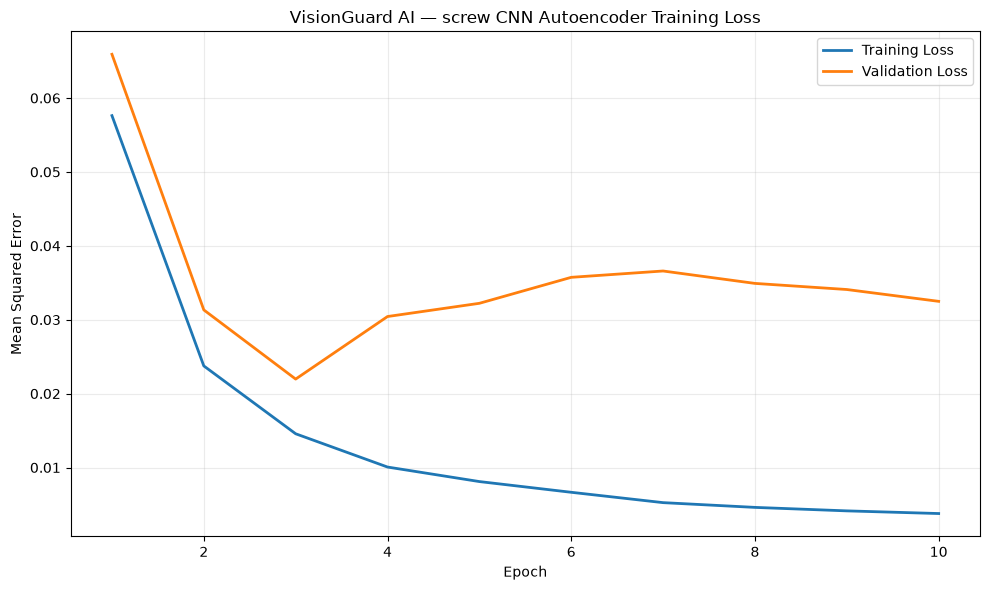

screw loss graphs saved.


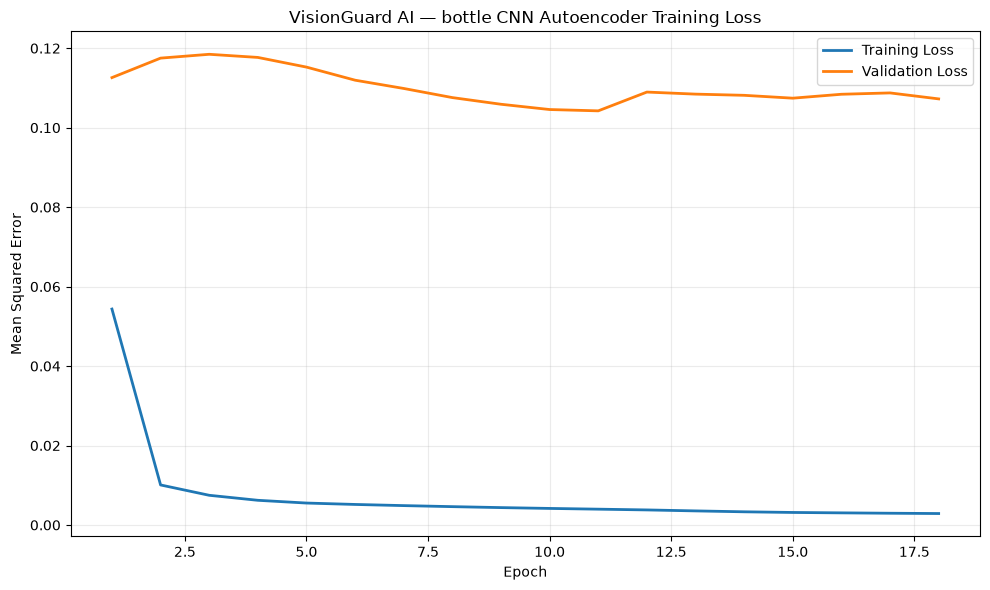

bottle loss graphs saved.


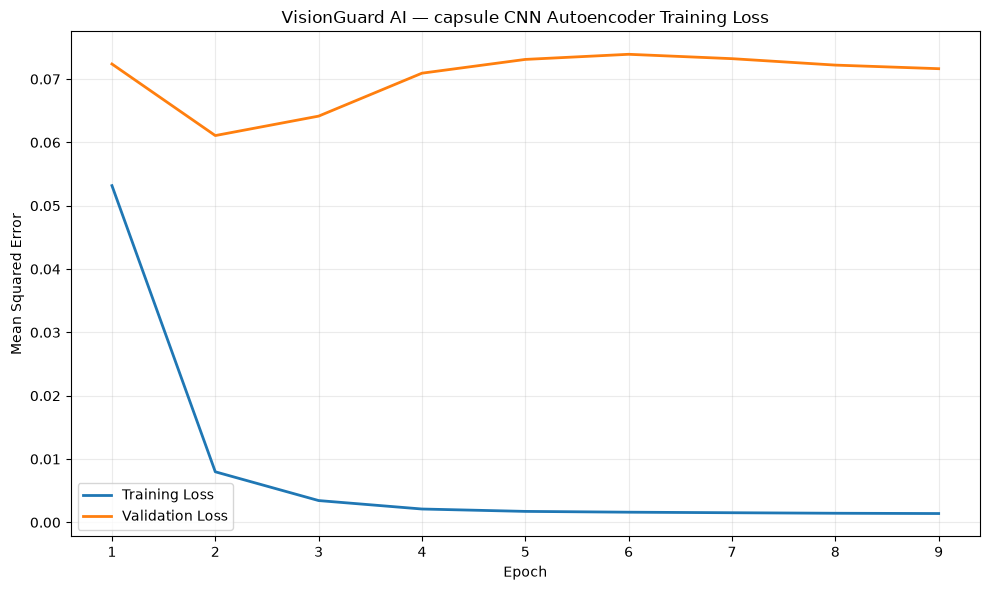

capsule loss graphs saved.


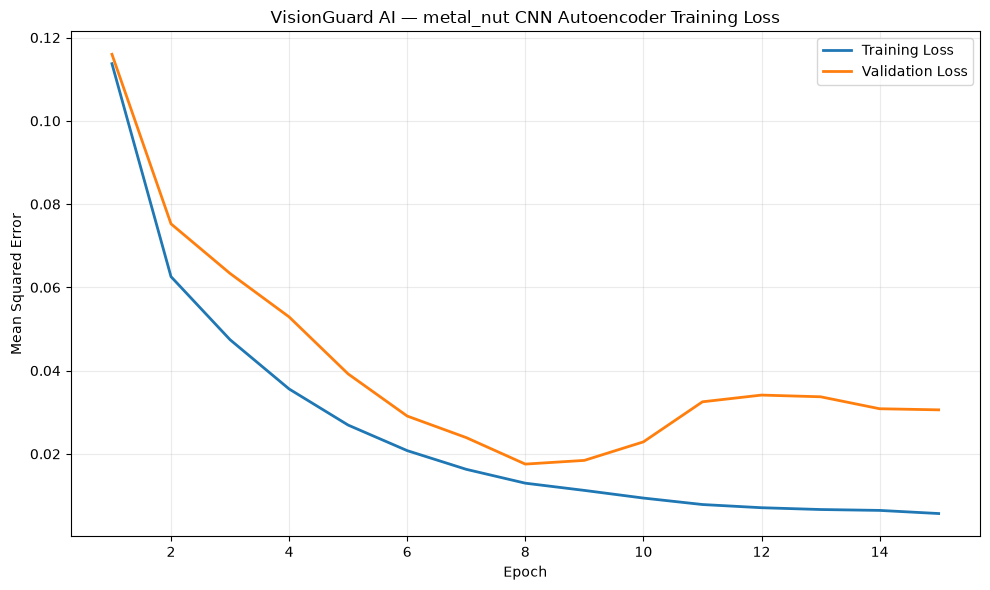

metal_nut loss graphs saved.


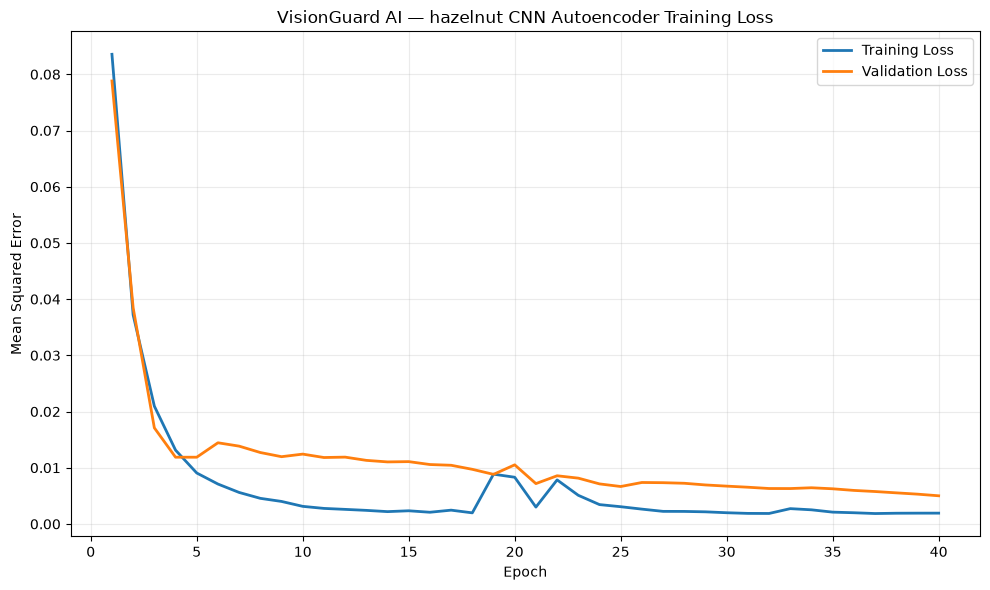

hazelnut loss graphs saved.


In [20]:
for category, history_df in history_tables.items():
    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.plot(
        history_df["Epoch"],
        history_df["loss"],
        label="Training Loss",
        linewidth=2,
    )

    ax.plot(
        history_df["Epoch"],
        history_df["val_loss"],
        label="Validation Loss",
        linewidth=2,
    )

    ax.set_title(
        f"VisionGuard AI — {category} "
        "CNN Autoencoder Training Loss"
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Mean Squared Error"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend()

    fig.tight_layout()

    png_file = (
        IMAGE_DIR /
        f"{category}_training_loss.png"
    )

    fig.savefig(
        png_file,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    html_file = (
        IMAGE_DIR /
        f"{category}_training_loss.html"
    )

    plotly_fig = go.Figure()

    plotly_fig.add_trace(
        go.Scatter(
            x=history_df["Epoch"],
            y=history_df["loss"],
            mode="lines+markers",
            name="Training Loss",
        )
    )

    plotly_fig.add_trace(
        go.Scatter(
            x=history_df["Epoch"],
            y=history_df["val_loss"],
            mode="lines+markers",
            name="Validation Loss",
        )
    )

    plotly_fig.update_layout(
        title=(
            f"VisionGuard AI — {category} "
            "CNN Autoencoder Training Loss"
        ),
        xaxis_title="Epoch",
        yaxis_title="Mean Squared Error",
        template="plotly_white",
    )

    plotly_fig.write_html(
        str(html_file),
        include_plotlyjs="cdn",
    )

    print(
        category,
        "loss graphs saved."
    )


## Training MAE graphs

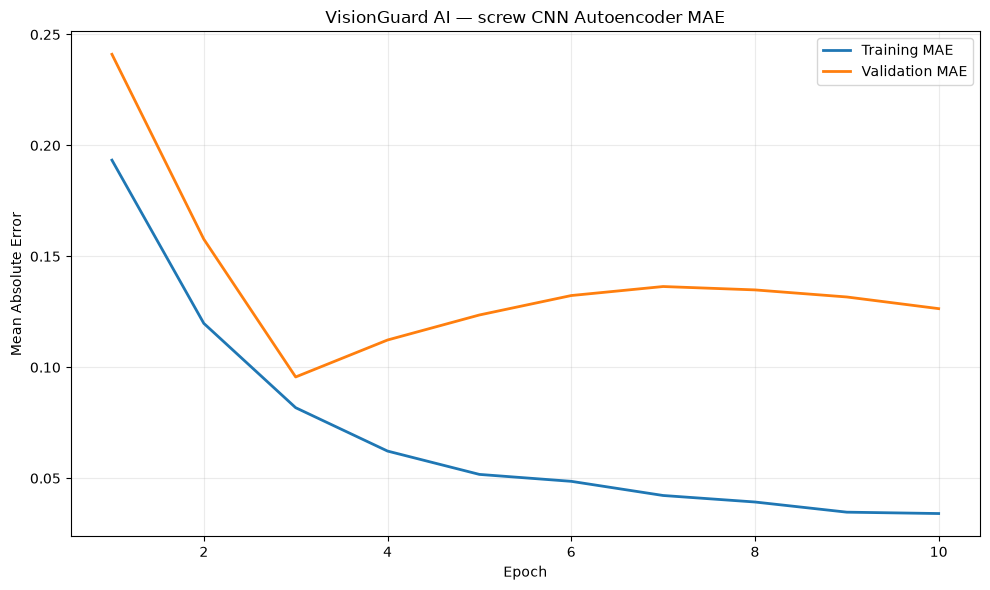

screw MAE graphs saved.


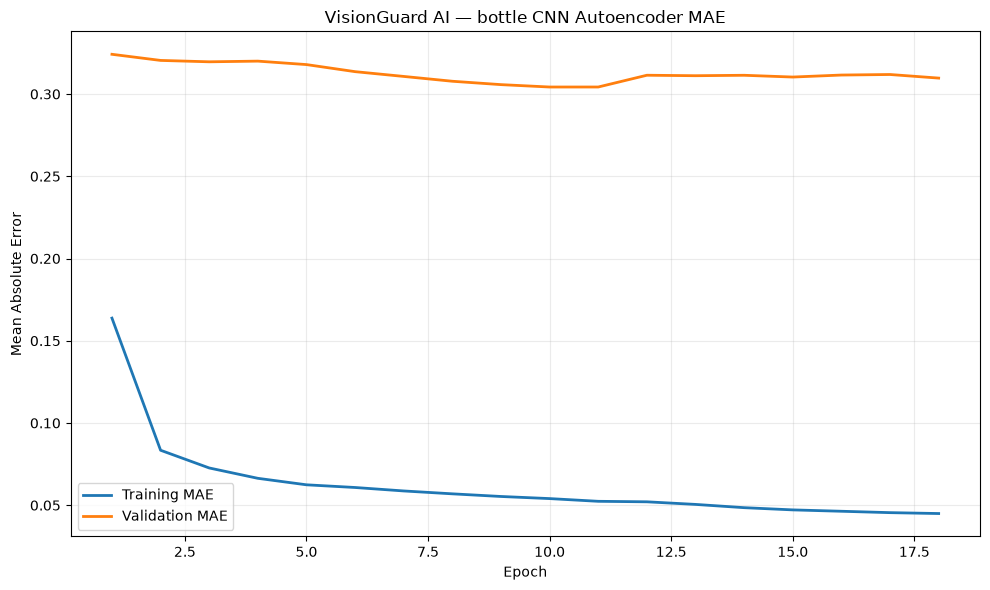

bottle MAE graphs saved.


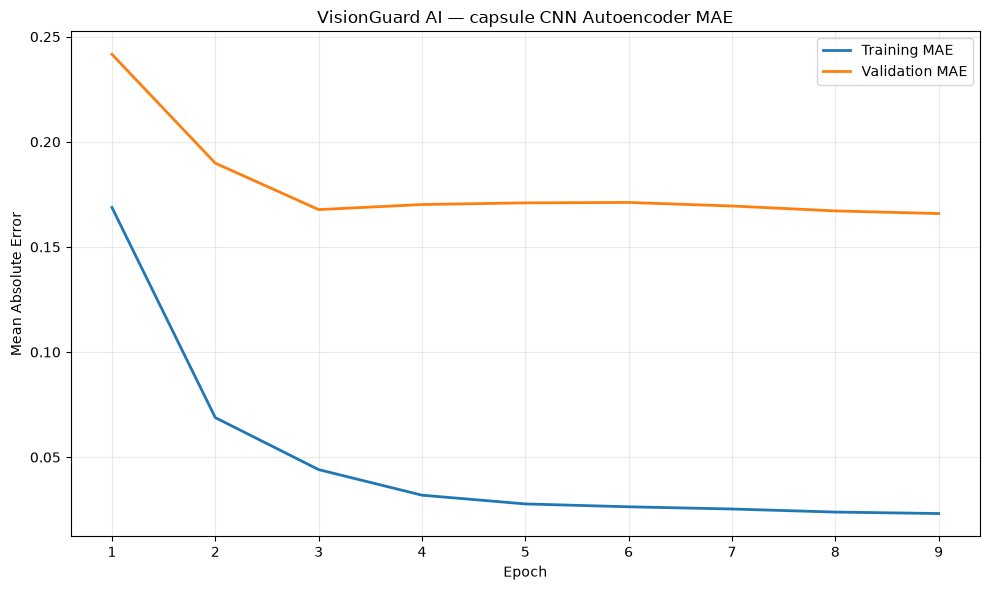

capsule MAE graphs saved.


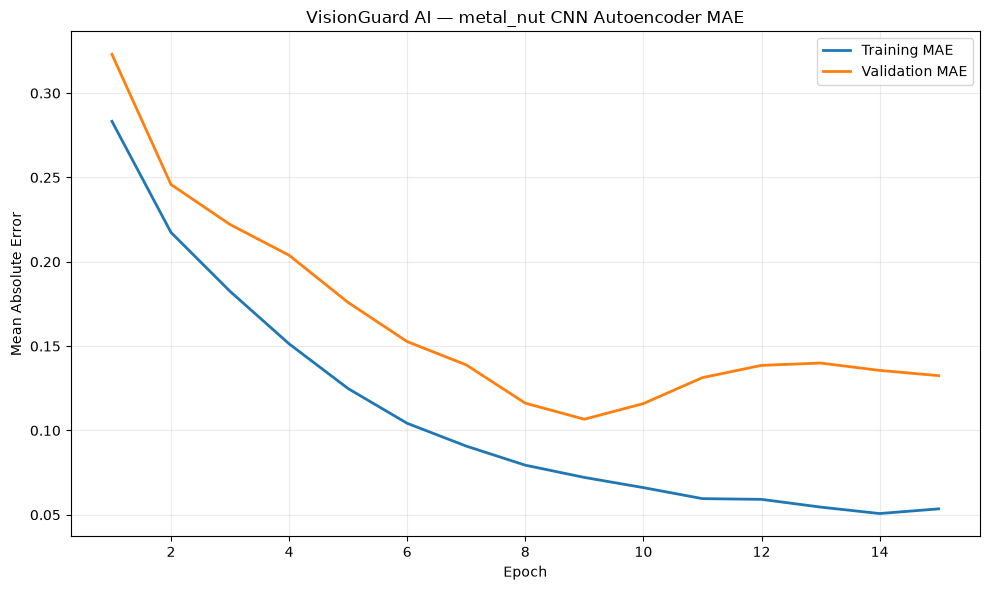

metal_nut MAE graphs saved.


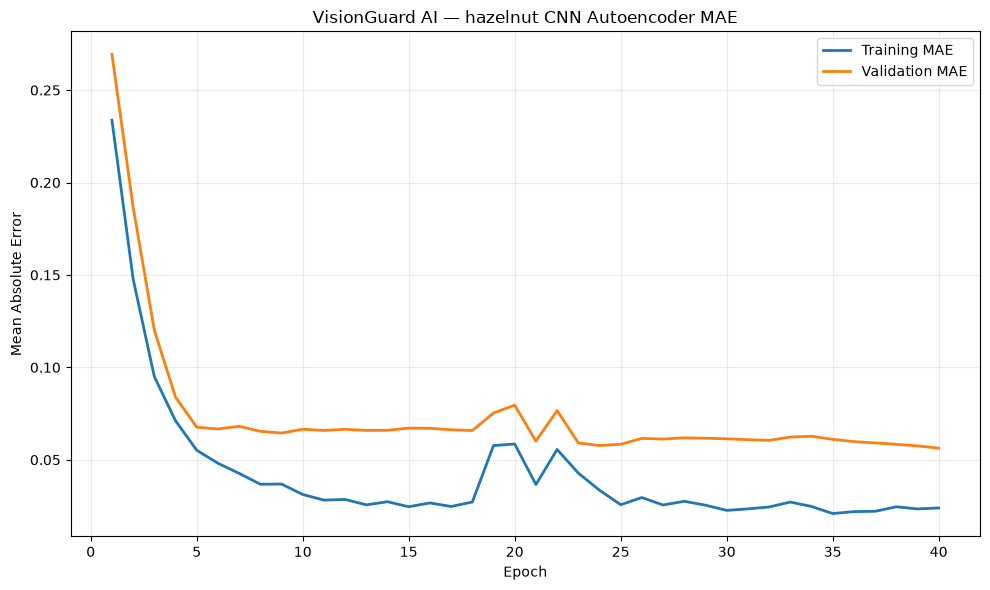

hazelnut MAE graphs saved.


In [21]:
for category, history_df in history_tables.items():
    if (
        "mae" not in history_df.columns
        or
        "val_mae" not in history_df.columns
    ):
        continue

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.plot(
        history_df["Epoch"],
        history_df["mae"],
        label="Training MAE",
        linewidth=2,
    )

    ax.plot(
        history_df["Epoch"],
        history_df["val_mae"],
        label="Validation MAE",
        linewidth=2,
    )

    ax.set_title(
        f"VisionGuard AI — {category} "
        "CNN Autoencoder MAE"
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Mean Absolute Error"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.legend()

    fig.tight_layout()

    png_file = (
        IMAGE_DIR /
        f"{category}_training_mae.png"
    )

    fig.savefig(
        png_file,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    html_file = (
        IMAGE_DIR /
        f"{category}_training_mae.html"
    )

    plotly_fig = go.Figure()

    plotly_fig.add_trace(
        go.Scatter(
            x=history_df["Epoch"],
            y=history_df["mae"],
            mode="lines+markers",
            name="Training MAE",
        )
    )

    plotly_fig.add_trace(
        go.Scatter(
            x=history_df["Epoch"],
            y=history_df["val_mae"],
            mode="lines+markers",
            name="Validation MAE",
        )
    )

    plotly_fig.update_layout(
        title=(
            f"VisionGuard AI — {category} "
            "CNN Autoencoder Mean Absolute Error"
        ),
        xaxis_title="Epoch",
        yaxis_title="Mean Absolute Error",
        template="plotly_white",
    )

    plotly_fig.write_html(
        str(html_file),
        include_plotlyjs="cdn",
    )

    print(
        category,
        "MAE graphs saved."
    )


## Reload the best saved models

In [22]:
best_models = {}

for category in CATEGORIES:
    best_file = model_records[
        category
    ]["best_model"]

    if not best_file.exists():
        raise FileNotFoundError(
            f"Best model was not saved for {category}."
        )

    best_models[
        category
    ] = keras.models.load_model(
        best_file
    )

print(
    "All best models reloaded."
)


All best models reloaded.


## Verify saved model inference

In [23]:
saved_model_rows = []

for category in CATEGORIES:
    model = best_models[
        category
    ]

    validation_dataset = make_dataset(
        split_data[
            category
        ]["validation"],
        training=False,
    )

    x, _ = next(
        iter(validation_dataset)
    )

    y = model.predict(
        x[:2],
        verbose=0,
    )

    assert y.shape == x[:2].shape

    saved_model_rows.append({
        "Category": category,
        "Input Shape": str(
            tuple(model.input_shape)
        ),
        "Output Shape": str(
            tuple(model.output_shape)
        ),
        "Parameters": int(
            model.count_params()
        ),
        "Best Model": model_records[
            category
        ]["best_model"].exists(),
        "Final Model": model_records[
            category
        ]["final_model"].exists(),
        "Best Weights": model_records[
            category
        ]["best_weights"].exists(),
        "Inference Passed": True,
    })

saved_model_df = pd.DataFrame(
    saved_model_rows
)

display(
    saved_model_df
)

saved_model_df.to_csv(
    TABLE_DIR /
    "saved_model_validation.csv",
    index=False,
)


,Category,Input Shape,Output Shape,Parameters,Best Model,Final Model,Best Weights,Inference Passed
0,screw,"(None, 128, 128, 3)","(None, 128, 128, 3)",778371,True,True,True,True
1,bottle,"(None, 128, 128, 3)","(None, 128, 128, 3)",778371,True,True,True,True
2,capsule,"(None, 128, 128, 3)","(None, 128, 128, 3)",778371,True,True,True,True
3,metal_nut,"(None, 128, 128, 3)","(None, 128, 128, 3)",778371,True,True,True,True
4,hazelnut,"(None, 128, 128, 3)","(None, 128, 128, 3)",778371,True,True,True,True


## Calculate normal validation reconstruction errors

In [24]:
def calculate_errors(
    model,
    paths,
):
    dataset = make_dataset(
        paths,
        training=False,
    )

    values = []

    for batch_x, _ in dataset:
        reconstruction = model(
            batch_x,
            training=False,
        )

        error = tf.reduce_mean(
            tf.square(
                batch_x -
                reconstruction
            ),
            axis=[
                1,
                2,
                3,
            ],
        )

        values.extend(
            error.numpy().tolist()
        )

    return np.asarray(
        values,
        dtype=np.float64,
    )


error_frames = []
threshold_rows = []

for category in CATEGORIES:
    validation_paths = split_data[
        category
    ]["validation"]

    errors = calculate_errors(
        best_models[
            category
        ],
        validation_paths,
    )

    if len(errors) != len(
        validation_paths
    ):
        raise RuntimeError(
            f"{category}: reconstruction error count mismatch."
        )

    category_df = pd.DataFrame({
        "Category": category,
        "File": [
            Path(path).name
            for path in validation_paths
        ],
        "Reconstruction Error": errors,
    })

    error_frames.append(
        category_df
    )

    threshold_rows.append({
        "Category": category,
        "Mean Error": float(
            np.mean(errors)
        ),
        "Standard Deviation": float(
            np.std(errors)
        ),
        "95th Percentile": float(
            np.percentile(
                errors,
                95,
            )
        ),
        "99th Percentile": float(
            np.percentile(
                errors,
                99,
            )
        ),
        "Maximum Error": float(
            np.max(errors)
        ),
    })

all_errors_df = pd.concat(
    error_frames,
    ignore_index=True,
)

threshold_df = pd.DataFrame(
    threshold_rows
)

display(
    threshold_df
)

all_errors_df.to_csv(
    TABLE_DIR /
    "validation_reconstruction_errors.csv",
    index=False,
)

threshold_df.to_csv(
    TABLE_DIR /
    "reference_reconstruction_thresholds.csv",
    index=False,
)


,Category,Mean Error,Standard Deviation,95th Percentile,99th Percentile,Maximum Error
0,screw,0.021968,0.001950,0.024515,0.024555,0.024556
1,bottle,0.104248,0.001407,0.105709,0.106137,0.106244
2,capsule,0.061080,0.002810,0.065554,0.066029,0.066140
3,metal_nut,0.017546,0.002870,0.023452,0.024446,0.024690
4,hazelnut,0.005013,0.001116,0.007375,0.008393,0.008848


## Reconstruction error graphs

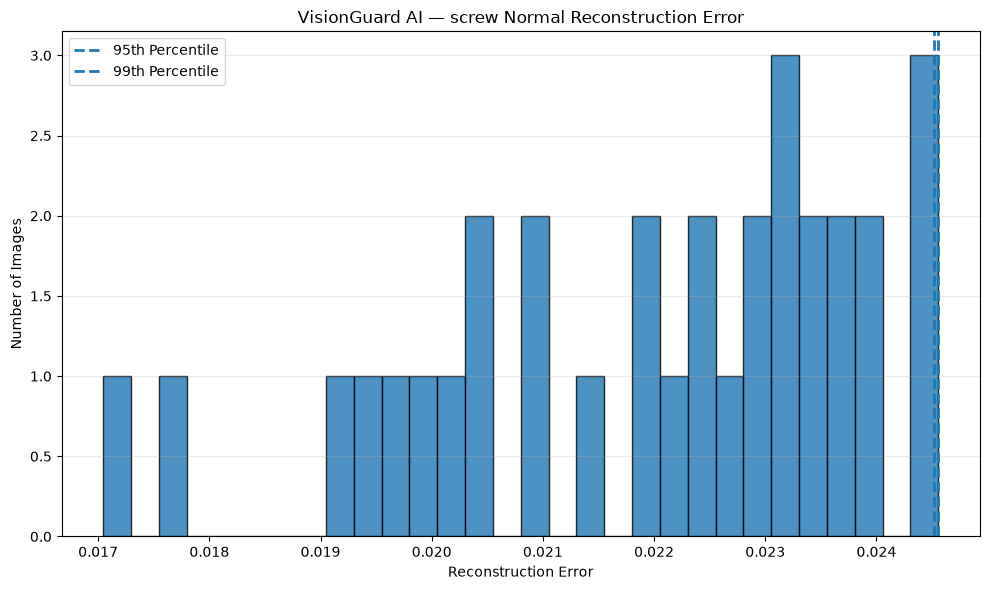

screw error graphs saved.


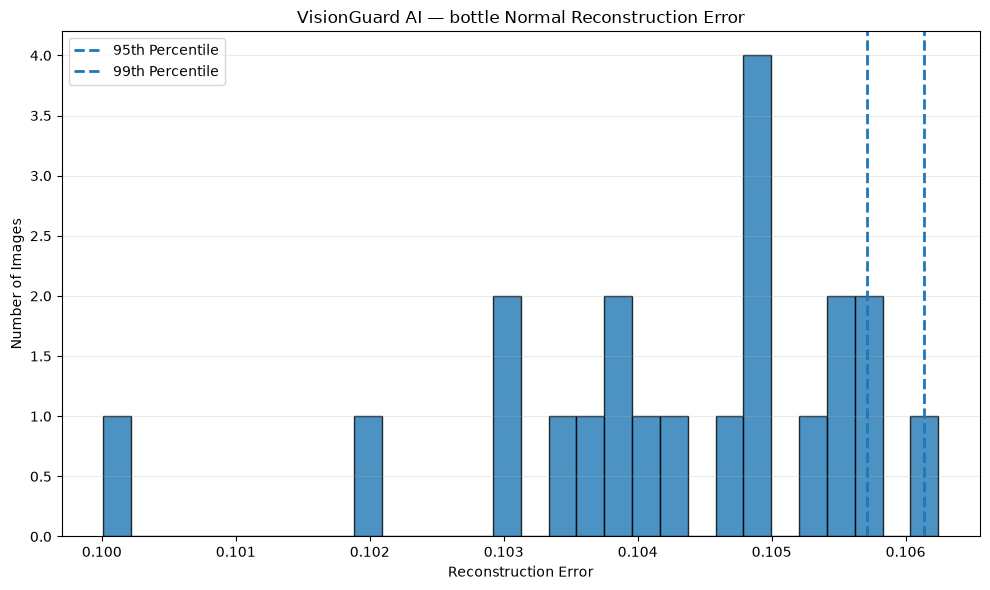

bottle error graphs saved.


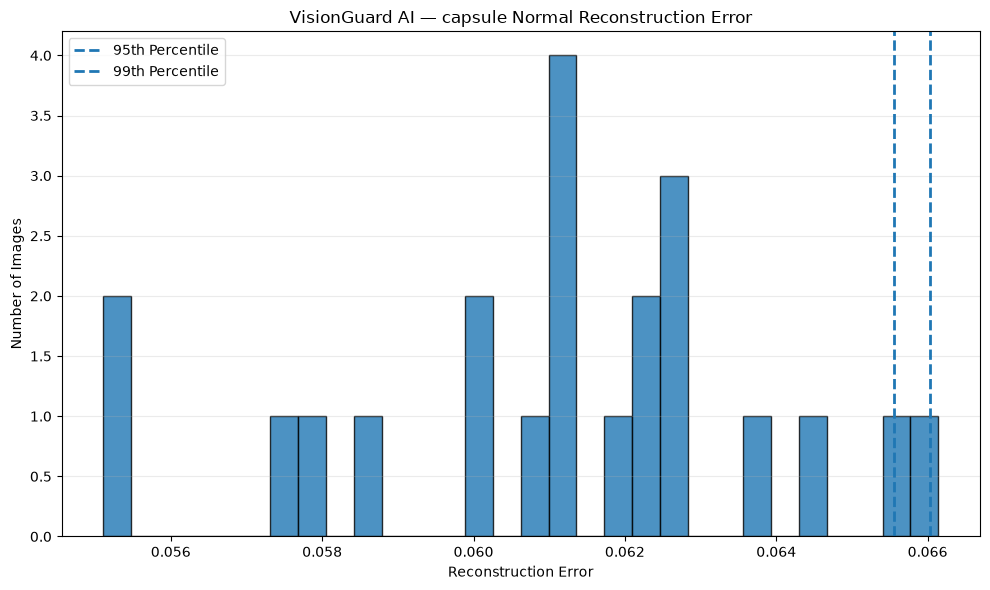

capsule error graphs saved.


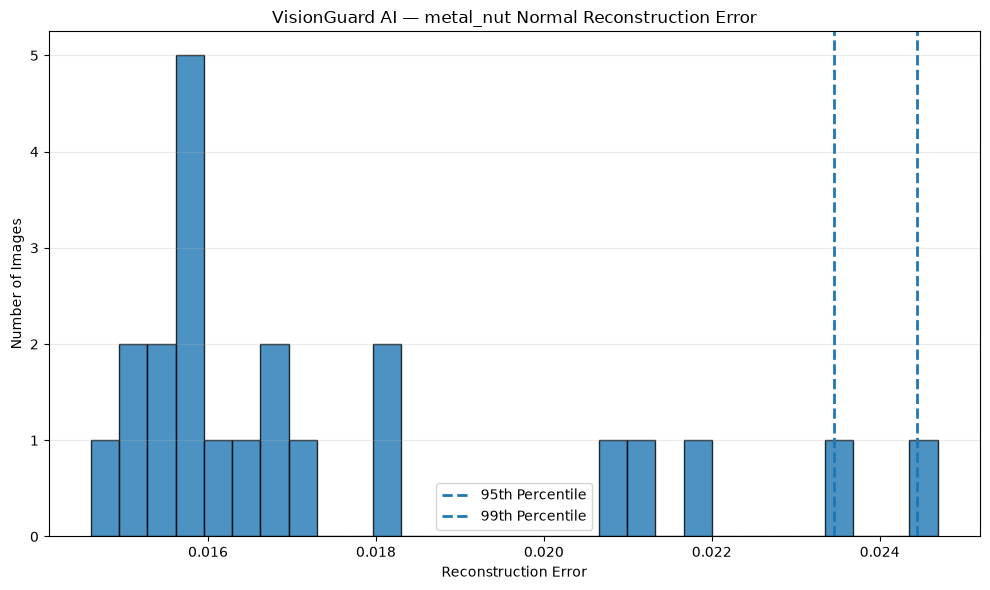

metal_nut error graphs saved.


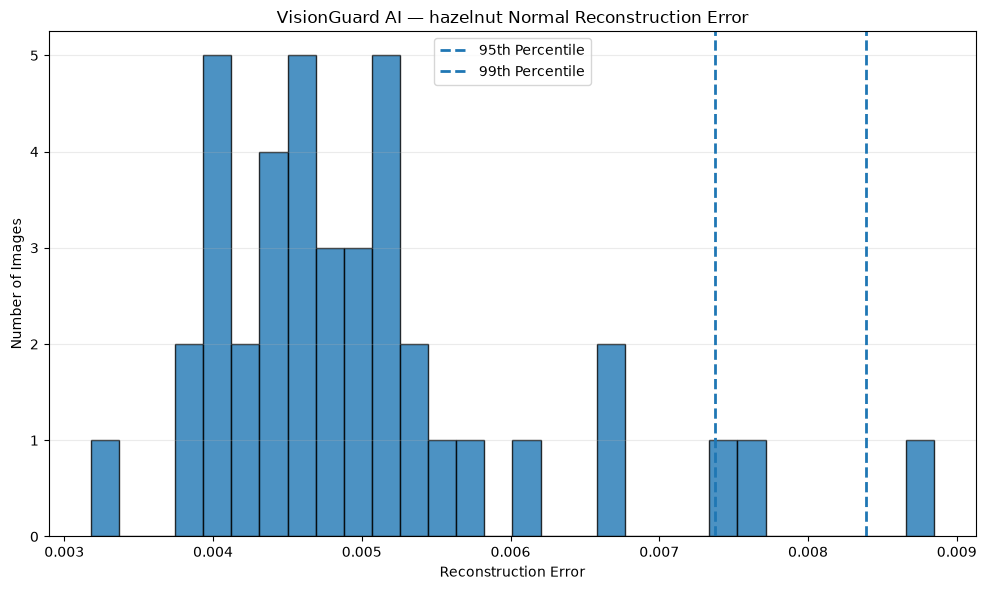

hazelnut error graphs saved.


In [25]:
for category in CATEGORIES:
    values = all_errors_df.loc[
        all_errors_df[
            "Category"
        ] == category,
        "Reconstruction Error",
    ].to_numpy()

    p95 = float(
        np.percentile(
            values,
            95,
        )
    )

    p99 = float(
        np.percentile(
            values,
            99,
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.hist(
        values,
        bins=30,
        edgecolor="black",
        alpha=0.8,
    )

    ax.axvline(
        p95,
        linestyle="--",
        linewidth=2,
        label="95th Percentile",
    )

    ax.axvline(
        p99,
        linestyle="--",
        linewidth=2,
        label="99th Percentile",
    )

    ax.set_title(
        f"VisionGuard AI — {category} "
        "Normal Reconstruction Error"
    )

    ax.set_xlabel(
        "Reconstruction Error"
    )

    ax.set_ylabel(
        "Number of Images"
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.25,
    )

    ax.legend()
    fig.tight_layout()

    png_file = (
        IMAGE_DIR /
        f"{category}_reconstruction_error.png"
    )

    fig.savefig(
        png_file,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    interactive = go.Figure(
        data=[
            go.Histogram(
                x=values,
                nbinsx=30,
            )
        ]
    )

    interactive.add_vline(
        x=p95,
        line_dash="dash",
        annotation_text="95th Percentile",
    )

    interactive.add_vline(
        x=p99,
        line_dash="dash",
        annotation_text="99th Percentile",
    )

    interactive.update_layout(
        title=(
            f"VisionGuard AI — {category} "
            "Normal Reconstruction Error"
        ),
        xaxis_title="Reconstruction Error",
        yaxis_title="Number of Images",
        template="plotly_white",
    )

    html_file = (
        IMAGE_DIR /
        f"{category}_reconstruction_error.html"
    )

    interactive.write_html(
        str(html_file),
        include_plotlyjs="cdn",
    )

    print(
        category,
        "error graphs saved."
    )


## Reconstruction preview images

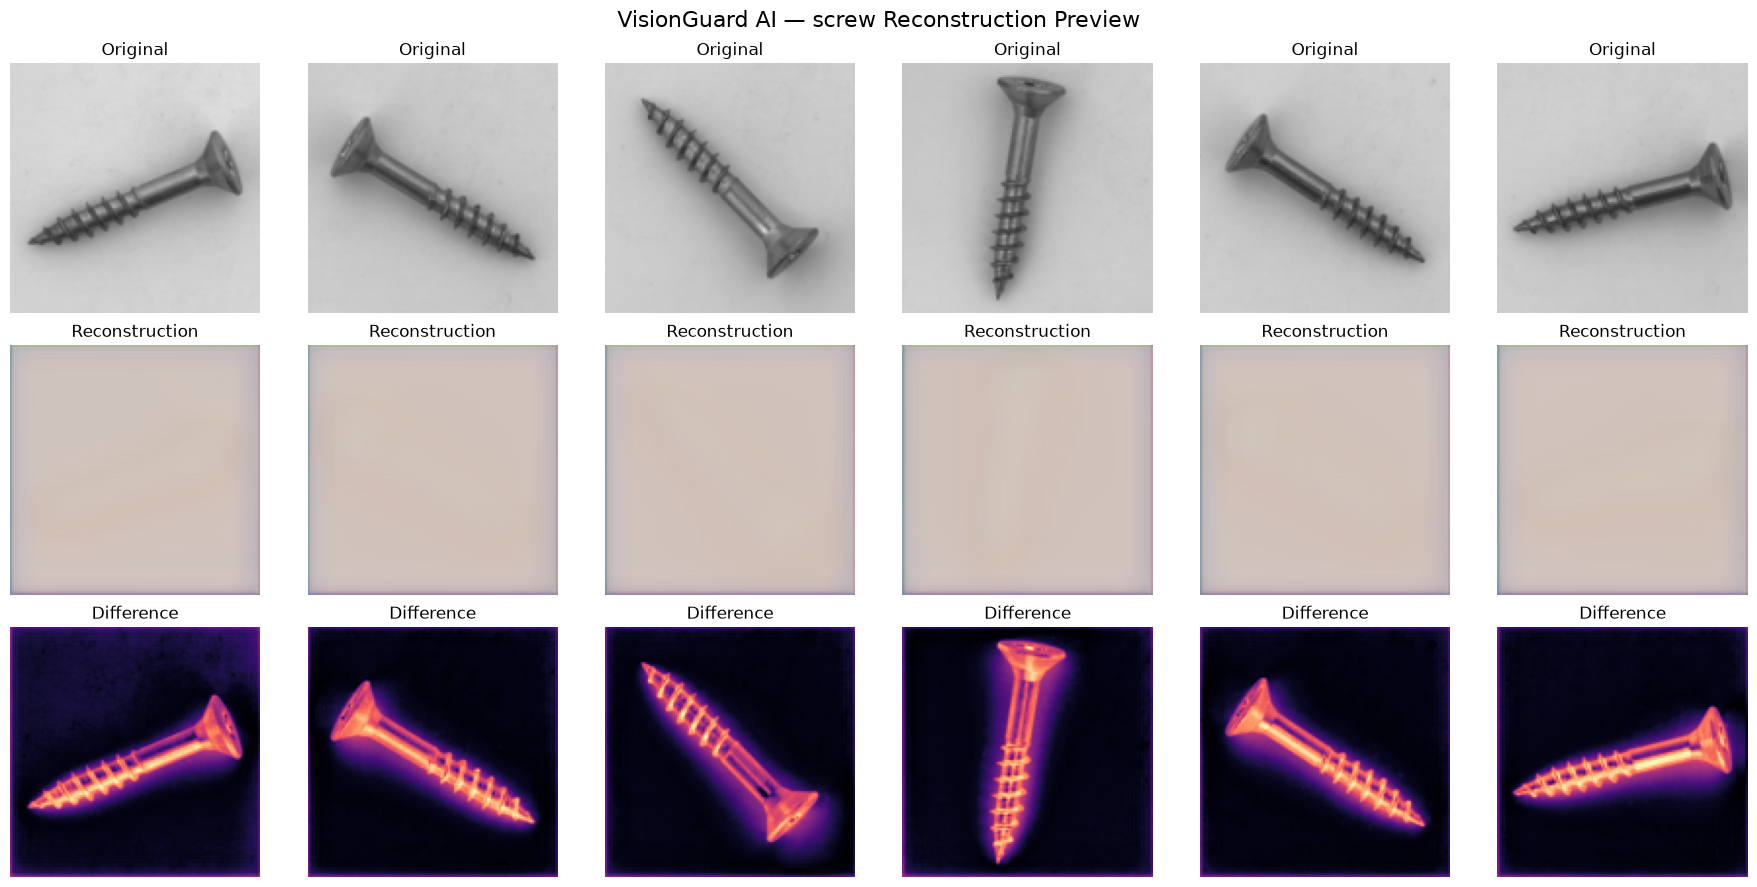

screw preview saved.


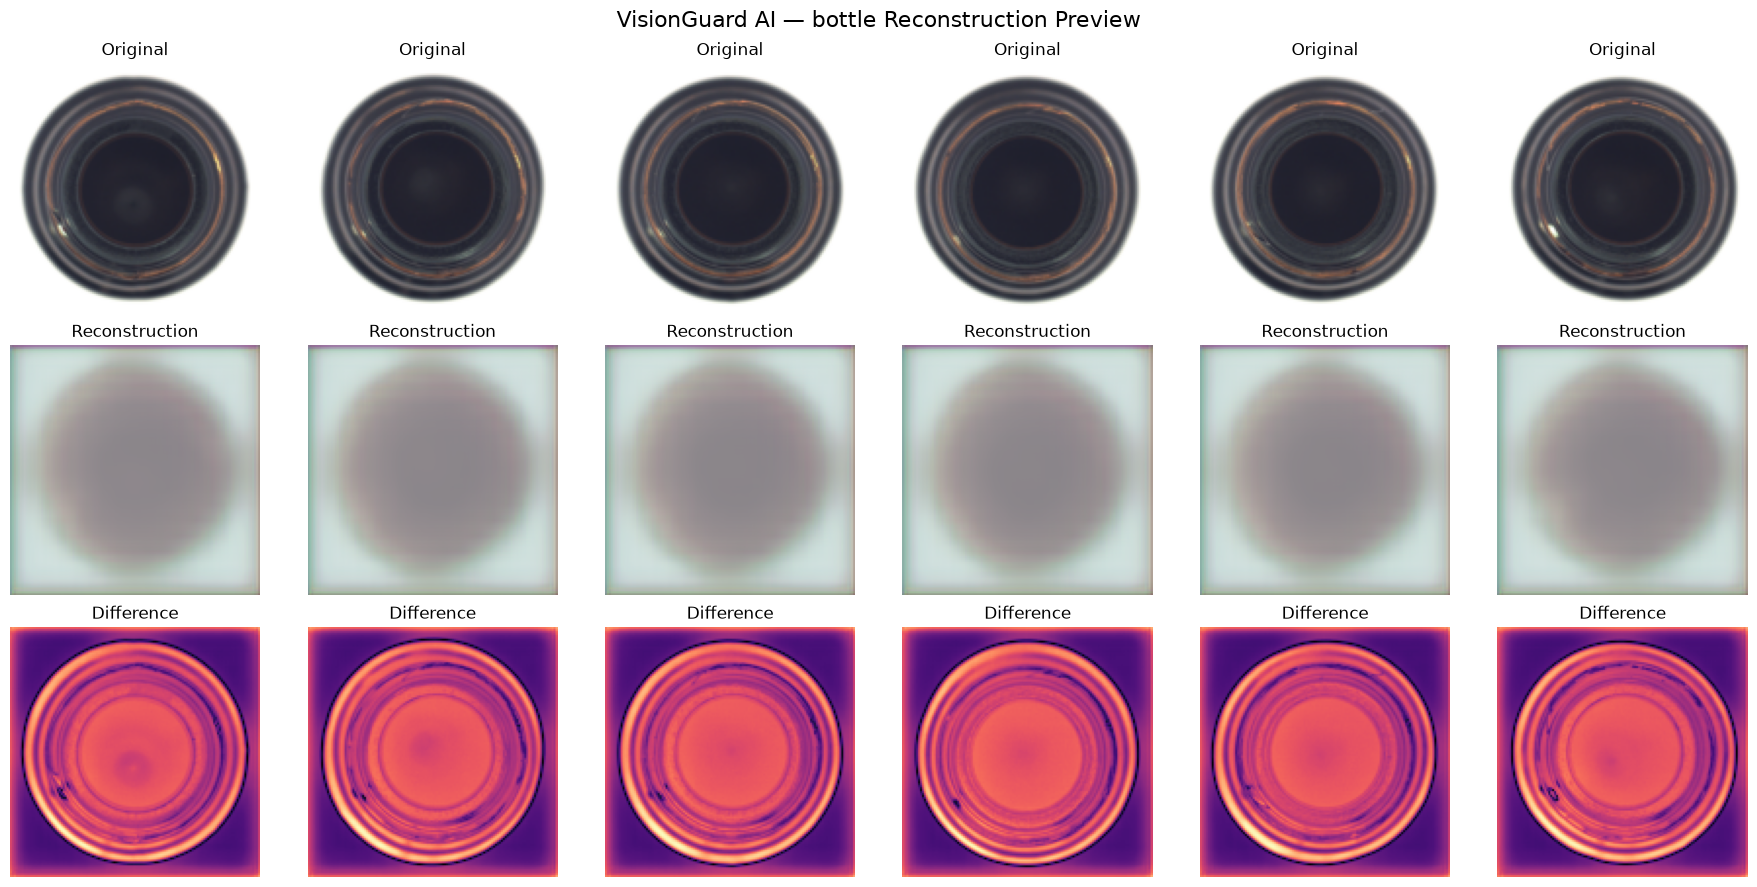

bottle preview saved.


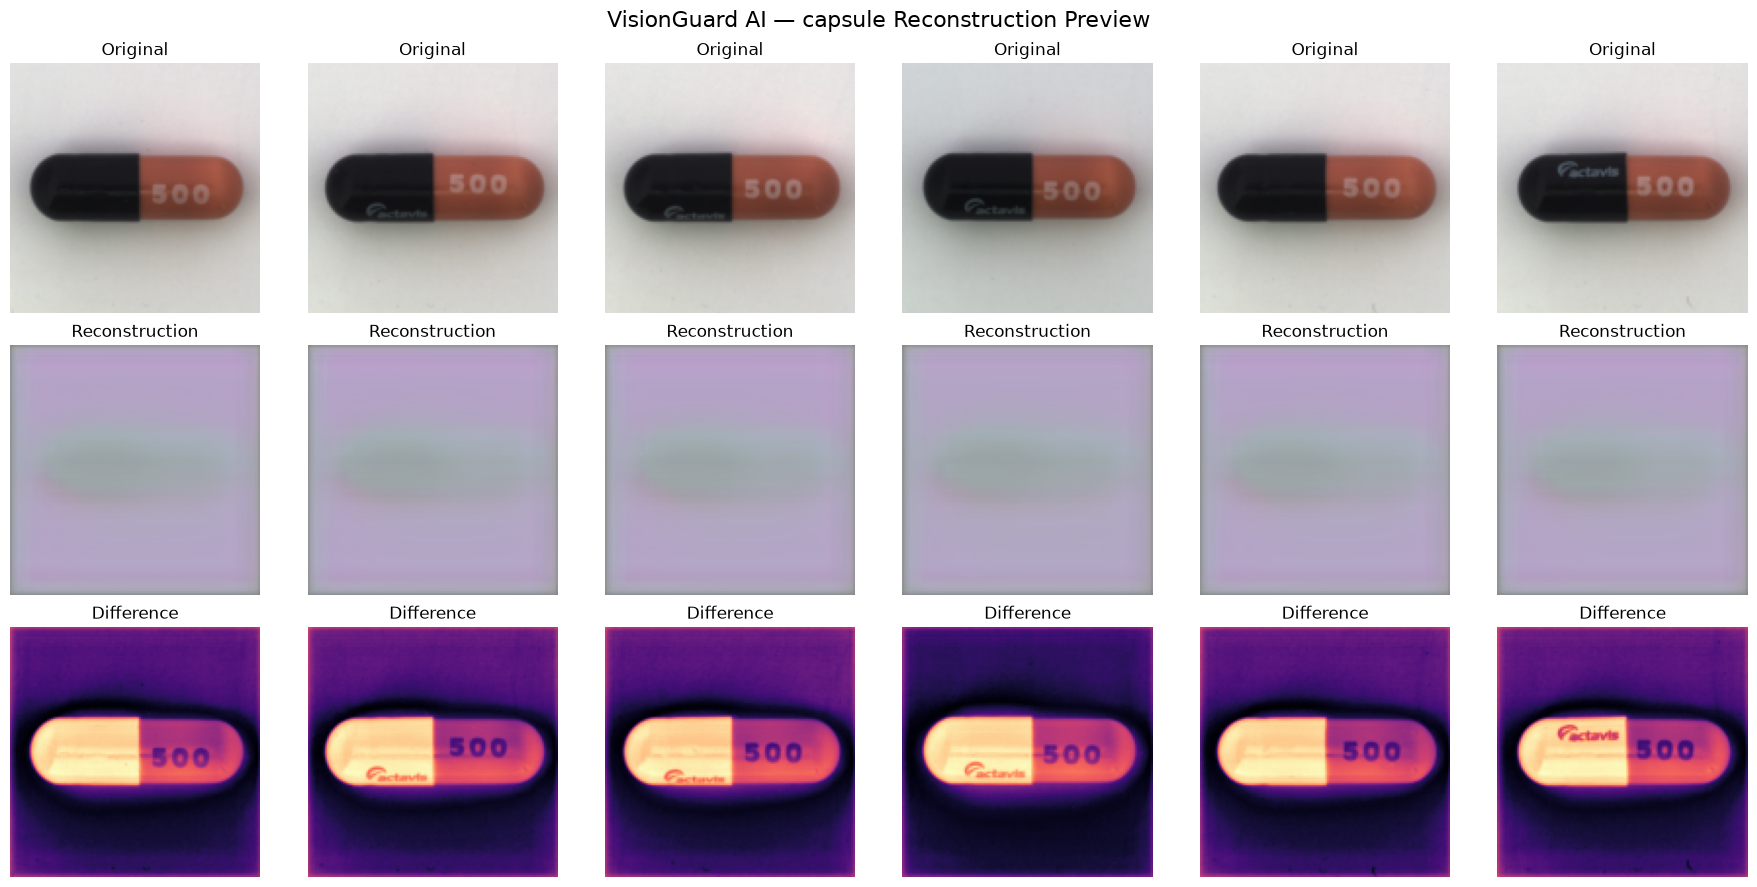

capsule preview saved.


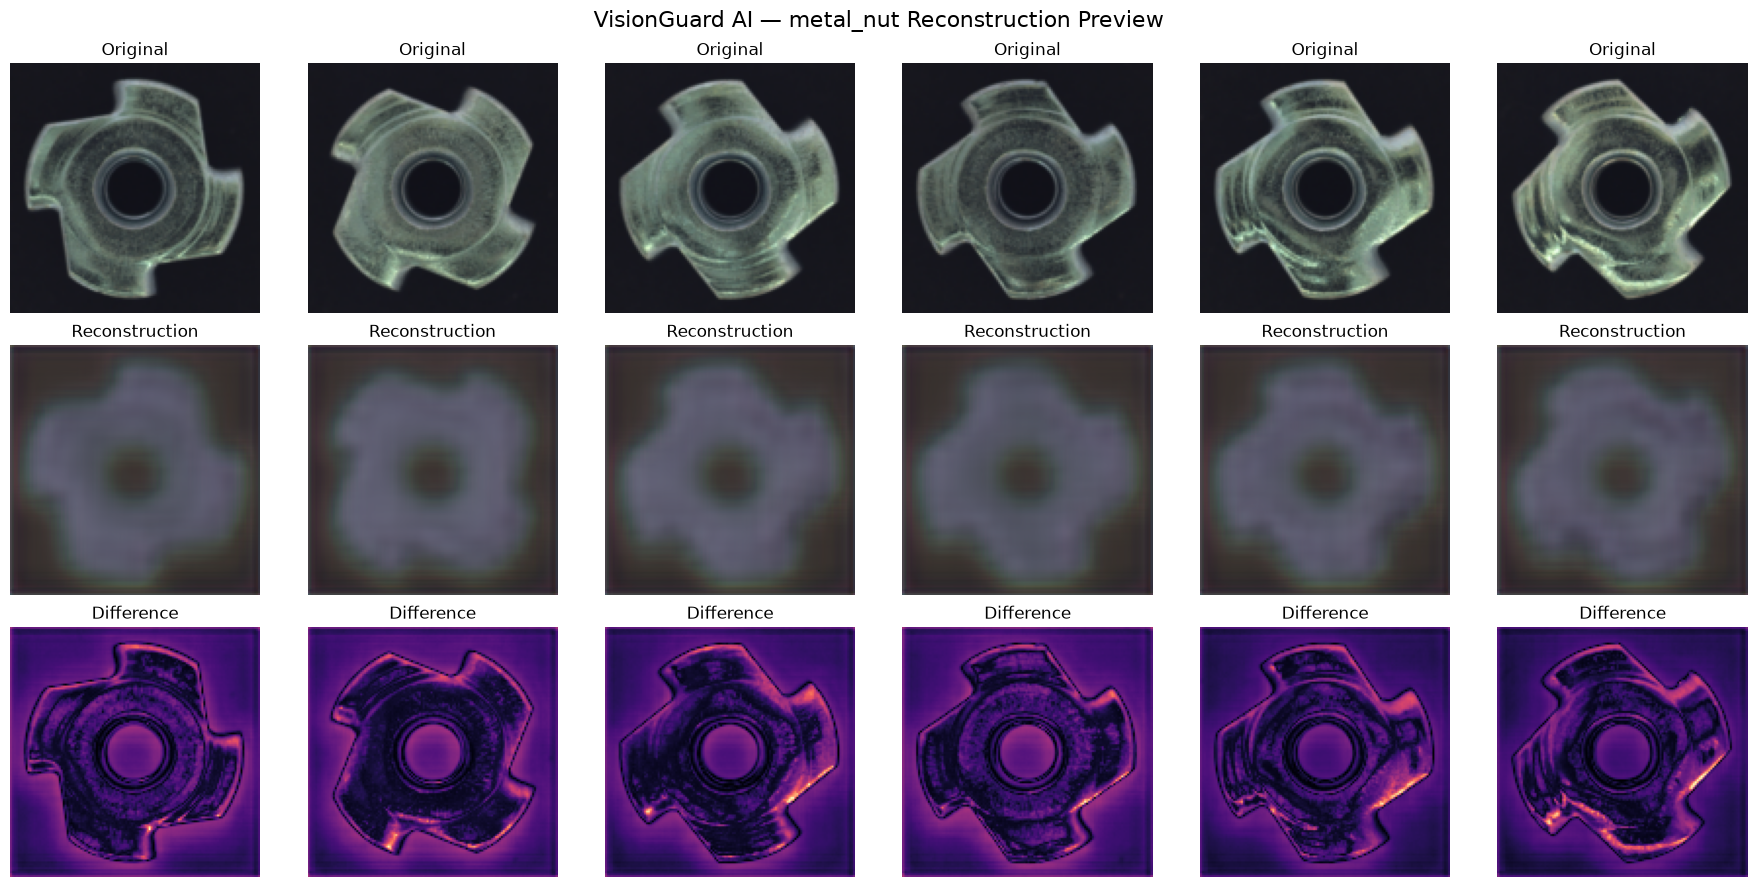

metal_nut preview saved.


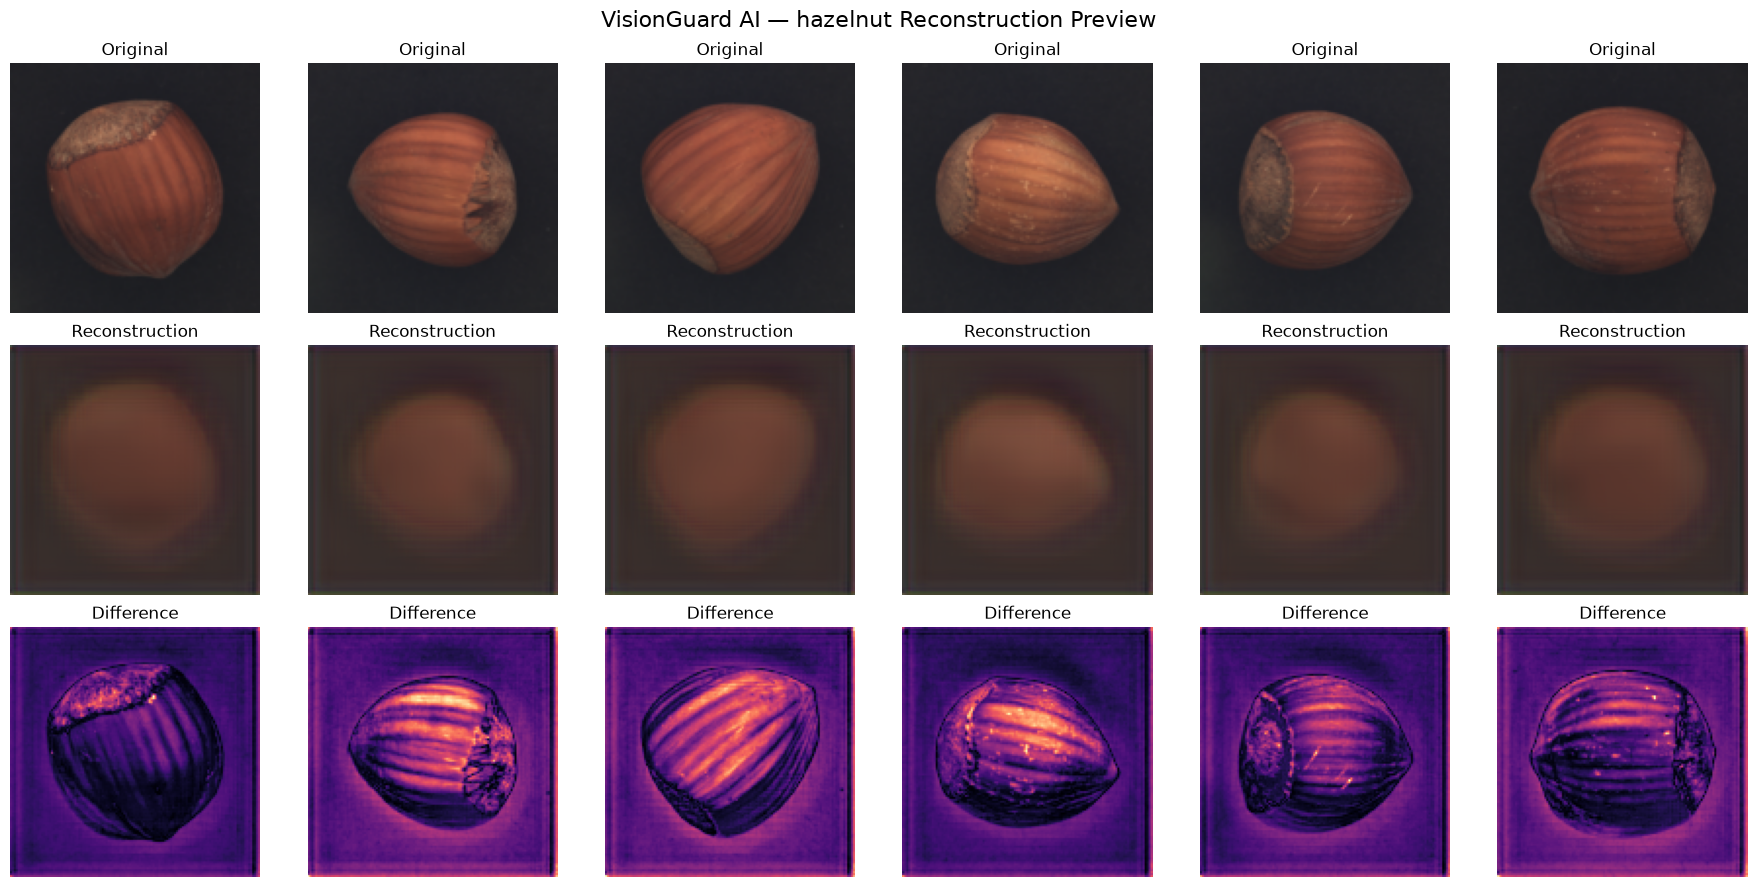

hazelnut preview saved.


In [26]:
for category in CATEGORIES:
    preview_paths = split_data[
        category
    ]["validation"][:6]

    original_images = np.stack([
        np.asarray(
            Image.open(path)
            .convert("RGB")
            .resize(
                (
                    IMAGE_WIDTH,
                    IMAGE_HEIGHT,
                ),
                resample=Image.Resampling.BILINEAR,
            ),
            dtype=np.float32,
        ) / 255.0
        for path in preview_paths
    ])

    reconstructed_images = best_models[
        category
    ].predict(
        original_images,
        verbose=0,
    )

    reconstructed_images = np.clip(
        reconstructed_images,
        0.0,
        1.0,
    )

    fig, axes = plt.subplots(
        3,
        len(original_images),
        figsize=(
            3 * len(original_images),
            9,
        ),
    )

    if len(original_images) == 1:
        axes = np.asarray(
            axes
        ).reshape(
            3,
            1,
        )

    for index in range(
        len(original_images)
    ):
        axes[
            0,
            index,
        ].imshow(
            original_images[index]
        )

        axes[
            0,
            index,
        ].set_title(
            "Original"
        )

        axes[
            0,
            index,
        ].axis("off")

        axes[
            1,
            index,
        ].imshow(
            reconstructed_images[index]
        )

        axes[
            1,
            index,
        ].set_title(
            "Reconstruction"
        )

        axes[
            1,
            index,
        ].axis("off")

        difference = np.mean(
            np.abs(
                original_images[index]
                -
                reconstructed_images[index]
            ),
            axis=-1,
        )

        axes[
            2,
            index,
        ].imshow(
            difference,
            cmap="magma",
        )

        axes[
            2,
            index,
        ].set_title(
            "Difference"
        )

        axes[
            2,
            index,
        ].axis("off")

    fig.suptitle(
        f"VisionGuard AI — {category} "
        "Reconstruction Preview",
        fontsize=16,
    )

    fig.tight_layout()

    file_name = (
        IMAGE_DIR /
        f"{category}_reconstruction_preview.png"
    )

    fig.savefig(
        file_name,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        category,
        "preview saved."
    )


## Final training report

In [27]:
final_rows = []

for category in CATEGORIES:
    history_df = history_tables[
        category
    ]

    best_index = int(
        history_df[
            "val_loss"
        ].idxmin()
    )

    best_row = history_df.iloc[
        best_index
    ]

    errors = all_errors_df.loc[
        all_errors_df[
            "Category"
        ] == category,
        "Reconstruction Error",
    ].to_numpy()

    final_rows.append({
        "Category": category,
        "Train Images": len(
            split_data[
                category
            ]["train"]
        ),
        "Validation Images": len(
            split_data[
                category
            ]["validation"]
        ),
        "Epochs Completed": len(
            history_df
        ),
        "Best Epoch": int(
            best_row["Epoch"]
        ),
        "Best Validation Loss": float(
            best_row[
                "val_loss"
            ]
        ),
        "Best Validation MAE": float(
            best_row.get(
                "val_mae",
                np.nan,
            )
        ),
        "Mean Normal Error": float(
            np.mean(errors)
        ),
        "95th Percentile Error": float(
            np.percentile(
                errors,
                95,
            )
        ),
        "99th Percentile Error": float(
            np.percentile(
                errors,
                99,
            )
        ),
    })

final_report_df = pd.DataFrame(
    final_rows
)

display(
    final_report_df
)

final_report_df.to_csv(
    TABLE_DIR /
    "final_training_report.csv",
    index=False,
)


,Category,Train Images,Validation Images,Epochs Completed,Best Epoch,Best Validation Loss,Best Validation MAE,Mean Normal Error,95th Percentile Error,99th Percentile Error
0,screw,288,32,10,3,0.021967,0.095629,0.021968,0.024515,0.024555
1,bottle,188,21,18,11,0.104238,0.304279,0.104248,0.105709,0.106137
2,capsule,197,22,9,2,0.061080,0.189850,0.061080,0.065554,0.066029
3,metal_nut,198,22,15,8,0.017547,0.116179,0.017546,0.023452,0.024446
4,hazelnut,351,40,40,40,0.005012,0.056306,0.005013,0.007375,0.008393


## Final artifact verification

In [28]:
artifact_rows = []

for category in CATEGORIES:
    artifact_rows.extend([
        {
            "Category": category,
            "Artifact": "Best Model",
            "Exists": model_records[
                category
            ]["best_model"].exists(),
        },
        {
            "Category": category,
            "Artifact": "Final Model",
            "Exists": model_records[
                category
            ]["final_model"].exists(),
        },
        {
            "Category": category,
            "Artifact": "Best Weights",
            "Exists": model_records[
                category
            ]["best_weights"].exists(),
        },
        {
            "Category": category,
            "Artifact": "Training History",
            "Exists": (
                TABLE_DIR /
                f"{category}_training_history.csv"
            ).exists(),
        },
        {
            "Category": category,
            "Artifact": "Training Loss PNG",
            "Exists": (
                IMAGE_DIR /
                f"{category}_training_loss.png"
            ).exists(),
        },
        {
            "Category": category,
            "Artifact": "Training Loss HTML",
            "Exists": (
                IMAGE_DIR /
                f"{category}_training_loss.html"
            ).exists(),
        },
    ])

artifact_df = pd.DataFrame(
    artifact_rows
)

display(
    artifact_df
)

artifact_df.to_csv(
    TABLE_DIR /
    "artifact_verification.csv",
    index=False,
)

print(
    "All artifacts verified."
    if artifact_df["Exists"].all()
    else "Some artifacts are missing."
)


,Category,Artifact,Exists
0,screw,Best Model,True
1,screw,Final Model,True
2,screw,Best Weights,True
3,screw,Training History,True
4,screw,Training Loss PNG,True
5,screw,Training Loss HTML,True
6,bottle,Best Model,True
7,bottle,Final Model,True
8,bottle,Best Weights,True
9,bottle,Training History,True


All artifacts verified.


## Final status

In [29]:
print("=" * 72)
print(
    "VISIONGUARD AI — CNN AUTOENCODER TRAINING"
)
print("=" * 72)

print(
    "Models trained:",
    len(best_models),
    "/",
    len(CATEGORIES),
)

print(
    "Training completed for:",
    ", ".join(best_models.keys()),
)

print(
    "CSV tables saved."
)

print(
    "PNG and Plotly HTML graphs saved."
)

print(
    "Best and final models saved."
)

print("=" * 72)


VISIONGUARD AI — CNN AUTOENCODER TRAINING
Models trained: 5 / 5
Training completed for: screw, bottle, capsule, metal_nut, hazelnut
CSV tables saved.
PNG and Plotly HTML graphs saved.
Best and final models saved.
